In [3]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# Download stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Load dataset
df = pd.read_csv(r'F:\pbl research\5th opetion\CrisisLexT6\combined final.csv',encoding='utf-8')
#df = pd.read_csv("your_dataset.csv")  # Change to your file path

# Preprocessing function
def clean_text(tweet):
    tweet = re.sub(r"http\S+|www\S+|https\S+", '', tweet, flags=re.MULTILINE)  # Remove URLs
    tweet = re.sub(r'\@\w+|\#', '', tweet)  # Remove mentions and hashtags
    tweet = tweet.lower()  # Convert to lowercase
    tweet = re.sub(r'[^\w\s]', '', tweet)  # Remove punctuation
    tweet = " ".join([word for word in tweet.split() if word not in stop_words])  # Remove stopwords
    return tweet

# Apply text cleaning
df['cleaned_text'] = df['tweet'].apply(clean_text)



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Charvi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
#Applying two feature exteaction techniques (BOW,TFIDF)


#First BOW


# Convert text to numerical representation (BoW)
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(df['cleaned_text'])  # Feature matrix
y = df['label']  # Target variable (on-topic/off-topic)

# Split dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42,stratify=y)

# Check class distribution after split
print("Training set class distribution:\n", y_train.value_counts())
print("Testing set class distribution:\n", y_test.value_counts())

Training set class distribution:
 label
on-topic     25969
off-topic    22096
Name: count, dtype: int64
Testing set class distribution:
 label
on-topic     6493
off-topic    5524
Name: count, dtype: int64


In [3]:
print("Using BOW")
print("\n")


# Train Logistic Regression model
print("📌 Logistic Regression Results:")
model = LogisticRegression(C=0.3)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print("Actual iterations used:", model.n_iter_)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print("\n")

#Naive  bayes

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize Naïve Bayes classifier
nb_model = MultinomialNB()

# Train the model on the training set
nb_model.fit(X_train, y_train)

# Predict on training and test sets
y_train_pred_nb = nb_model.predict(X_train)
y_test_pred_nb = nb_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred_nb)
test_accuracy = accuracy_score(y_test, y_test_pred_nb)

# Print results
print("📌 Naïve Bayes Results:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_test_pred_nb))
print("\n")



#svm
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize SVM model with a linear kernel
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Predict on training and test data
y_train_pred_svm = svm_model.predict(X_train)
y_test_pred_svm = svm_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred_svm)
test_accuracy = accuracy_score(y_test, y_test_pred_svm)

# Print results
print("📌 Support Vector Machine (SVM) Results:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_test_pred_svm))
print("\n")


#random forset
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train,y_train_pred_rf)
test_accuracy = accuracy_score(y_test, y_test_pred_rf)

# Evaluate model
print("📌 Random Forest Results:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(classification_report(y_test, y_test_pred_rf))
print("\n")


#decision trees
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize Decision Tree classifier
dt_model = DecisionTreeClassifier(max_depth=20, random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predictions
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Calculate Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print results
print("📌 Decision Tree Results:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_test_pred))
print("\n")


#kNN
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN classifier with 5 neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Predictions
y_train_pred = knn_model.predict(X_train)
y_test_pred = knn_model.predict(X_test)

# Calculate Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print results
print("📌 KNN Results:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_test_pred))
print("\n")


Using BOW


📌 Logistic Regression Results:
Actual iterations used: [28]
Accuracy: 0.9482
Classification Report:
               precision    recall  f1-score   support

   off-topic       0.94      0.95      0.94      5524
    on-topic       0.96      0.95      0.95      6493

    accuracy                           0.95     12017
   macro avg       0.95      0.95      0.95     12017
weighted avg       0.95      0.95      0.95     12017

Training Accuracy: 0.9590
Testing Accuracy: 0.9482


📌 Naïve Bayes Results:
Training Accuracy: 0.9320
Testing Accuracy: 0.9150

Classification Report on Test Data:
              precision    recall  f1-score   support

   off-topic       0.91      0.91      0.91      5524
    on-topic       0.92      0.92      0.92      6493

    accuracy                           0.92     12017
   macro avg       0.91      0.91      0.91     12017
weighted avg       0.92      0.92      0.92     12017



📌 Support Vector Machine (SVM) Results:
Training Accuracy: 0.9844
T

In [4]:

#second  TF-IDF


# Use TF-IDF instead of CountVectorizer
vectorizer = TfidfVectorizer()

# Convert text to numerical representation (TF/IDF)
X_td = vectorizer.fit_transform(df['cleaned_text'])  # Feature matrix
y = df['label']  # Target variable (on-topic/off-topic)
# Transform data
#X_train = vectorizer.fit_transform(train_texts)
#X_test = vectorizer.transform(test_texts)

# Split dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_td, y, test_size=0.2, random_state=42,stratify=y)


In [5]:
print("Using TF-IDF")
print("\n")


# Train Logistic Regression model
print("📌 Logistic Regression Results:")
model = LogisticRegression(C=0.3)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print("Actual iterations used:", model.n_iter_)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print("\n")



#Naive  bayes

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize Naïve Bayes classifier
nb_model = MultinomialNB()

# Train the model on the training set
nb_model.fit(X_train, y_train)

# Predict on training and test sets
y_train_pred_nb = nb_model.predict(X_train)
y_test_pred_nb = nb_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred_nb)
test_accuracy = accuracy_score(y_test, y_test_pred_nb)

# Print results
print("📌 Naïve Bayes Results:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_test_pred_nb))
print("\n")



#svm
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize SVM model with a linear kernel
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Predict on training and test data
y_train_pred_svm = svm_model.predict(X_train)
y_test_pred_svm = svm_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred_svm)
test_accuracy = accuracy_score(y_test, y_test_pred_svm)

# Print results
print("📌 Support Vector Machine (SVM) Results:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_test_pred_svm))
print("\n")


#random forset
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train,y_train_pred_rf)
test_accuracy = accuracy_score(y_test, y_test_pred_rf)

# Evaluate model
print("📌 Random Forest Results:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(classification_report(y_test, y_test_pred_rf))
print("\n")



#decision trees
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize Decision Tree classifier
dt_model = DecisionTreeClassifier(max_depth=20, random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predictions
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Calculate Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print results
print("📌 Decision Tree Results:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_test_pred))
print("\n")



#kNN
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN classifier with 5 neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Predictions
y_train_pred = knn_model.predict(X_train)
y_test_pred = knn_model.predict(X_test)

# Calculate Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print results
print("📌 KNN Results:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_test_pred))
print("\n")


Using TF-IDF


📌 Logistic Regression Results:
Actual iterations used: [20]
Accuracy: 0.9331
Classification Report:
               precision    recall  f1-score   support

   off-topic       0.91      0.95      0.93      5524
    on-topic       0.96      0.92      0.94      6493

    accuracy                           0.93     12017
   macro avg       0.93      0.93      0.93     12017
weighted avg       0.93      0.93      0.93     12017

Training Accuracy: 0.9394
Testing Accuracy: 0.9331


📌 Naïve Bayes Results:
Training Accuracy: 0.9247
Testing Accuracy: 0.8987

Classification Report on Test Data:
              precision    recall  f1-score   support

   off-topic       0.91      0.87      0.89      5524
    on-topic       0.89      0.93      0.91      6493

    accuracy                           0.90     12017
   macro avg       0.90      0.90      0.90     12017
weighted avg       0.90      0.90      0.90     12017



📌 Support Vector Machine (SVM) Results:
Training Accuracy: 0.966

Using BOW




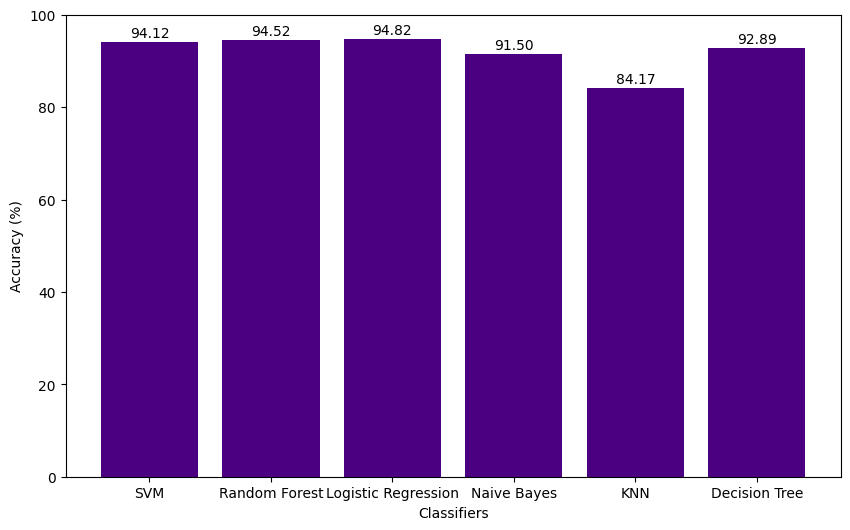

<Figure size 640x480 with 0 Axes>

In [1]:
import matplotlib.pyplot as plt
print("Using BOW")
print("\n")

# Classifier names
classifiers = ['SVM', 'Random Forest', 'Logistic Regression', 'Naive Bayes', 'KNN', 'Decision Tree']
# BoW accuracies
bow_accuracies = [94.12, 94.52, 94.82, 91.50, 84.17, 92.89]

plt.figure(figsize=(10, 6))
bars = plt.bar(classifiers, bow_accuracies, color='indigo')

plt.xlabel('Classifiers')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.2f}', ha='center')

#fig.subplots_adjust(bottom=0.2)  # leave space at bottom
#fig.suptitle('Classifier Accuracy Comparison using Bag of Words (BoW)', fontsize=14, y=0.05)

plt.show()    
#plt.title('Classifier Accuracy Comparison using Bag of Words (BoW)', fontsize=14)
plt.tight_layout()
plt.show()


Using TD-IDF




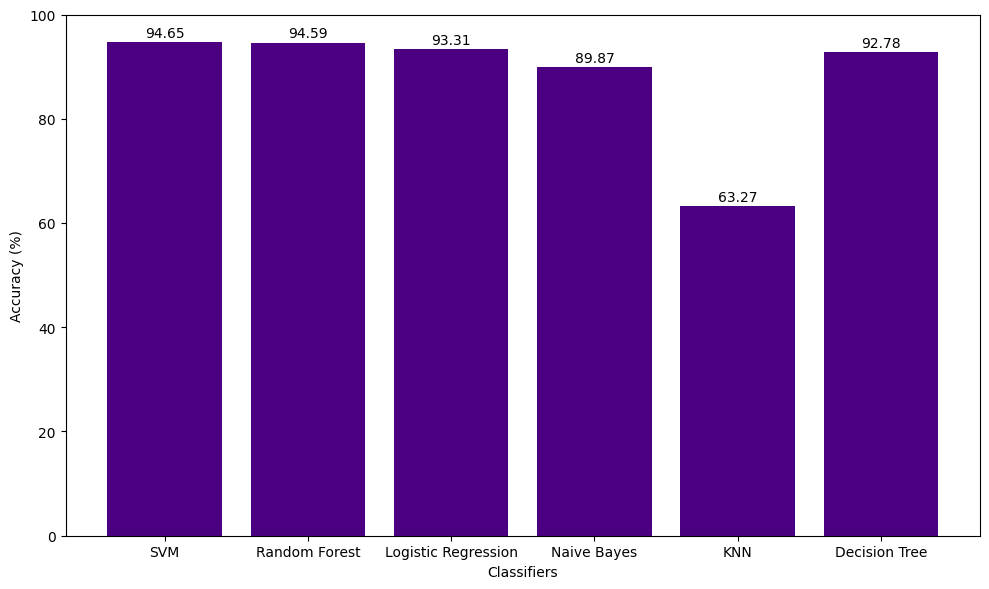

In [4]:
import matplotlib.pyplot as plt
print("Using TD-IDF")
print("\n")

# Classifier names
classifiers = ['SVM', 'Random Forest', 'Logistic Regression', 'Naive Bayes', 'KNN', 'Decision Tree']
# TF-IDF accuracies
tfidf_accuracies = [94.65, 94.59, 93.31, 89.87, 63.27, 92.78]

plt.figure(figsize=(10, 6))
bars = plt.bar(classifiers, tfidf_accuracies, color='indigo')
# plt.title('Classifier Accuracy Comparison using TF-IDF', fontsize=14)
plt.xlabel('Classifiers')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.2f}', ha='center')

plt.tight_layout()
plt.show()